EDA


Split
Test     1064
Train    8047
Val      1554
Name: Count, dtype: int64


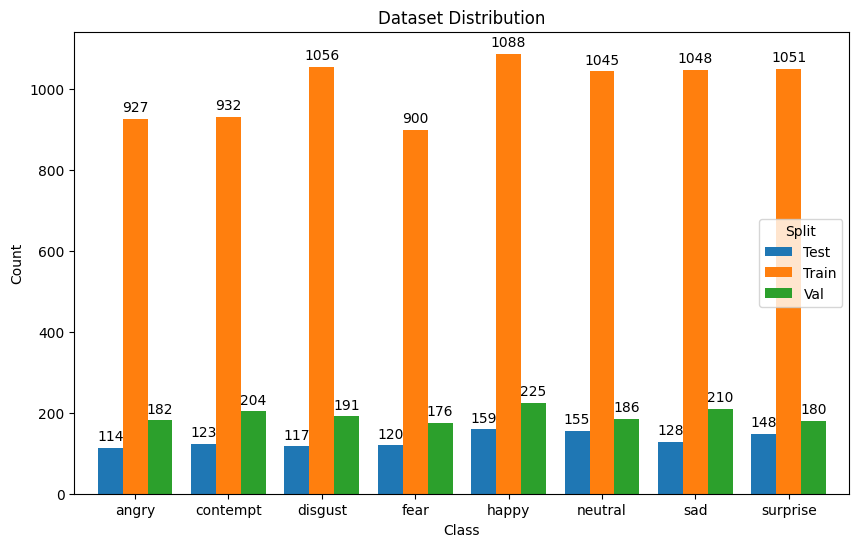

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}


def resolve_dataset_path(name='dataset'):
    candidates = [Path(name), Path.cwd() / name, Path.cwd().parent / name]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(f"Cannot find '{name}' from working directory: {Path.cwd()}")


DATASET_DIR = resolve_dataset_path('dataset')


def count_images(path):
    return sum(
        1
        for file_path in Path(path).iterdir()
        if file_path.is_file() and file_path.suffix.lower() in IMAGE_EXTENSIONS
    )

def get_distribution_old(root_path):
    root = Path(root_path)
    data = []
    
    # Quét qua các thư mục con cấp 1 (Train, Val, Test)
    for split_dir in root.iterdir():
        if split_dir.is_dir():
            # Quét qua các thư mục lớp (anger, happy...)
            for class_dir in split_dir.iterdir():
                if class_dir.is_dir():
                    count = len(list(class_dir.glob('*')))
                    data.append({
                        'Split': split_dir.name,
                        'Class': class_dir.name,
                        'Count': count
                    })
    return pd.DataFrame(data)


def get_distribution(root_path=DATASET_DIR):
    root = Path(root_path)
    if not root.exists():
        raise FileNotFoundError(f"Dataset folder does not exist: {root}")

    data = []
    first_level_dirs = [path for path in root.iterdir() if path.is_dir()]
    has_split_layout = any(any(child.is_dir() for child in path.iterdir()) for path in first_level_dirs)

    if has_split_layout:
        for split_dir in first_level_dirs:
            class_dirs = [path for path in split_dir.iterdir() if path.is_dir()]
            for class_dir in class_dirs:
                data.append({
                    'Split': split_dir.name,
                    'Class': class_dir.name,
                    'Count': count_images(class_dir)
                })
    else:
        for class_dir in first_level_dirs:
            data.append({
                'Split': 'All',
                'Class': class_dir.name,
                'Count': count_images(class_dir)
            })

    if not data:
        raise ValueError(f"No class folders found in dataset folder: {root}")
    return pd.DataFrame(data)


df = get_distribution(DATASET_DIR)


def plot_data_distribution(df):
  plot_df = df.pivot(index = 'Class', columns = 'Split', values = 'Count')
  ax = plot_df.plot(kind = 'bar',figsize = (10, 6), width = 0.8) 
  for container in ax.containers:
    ax.bar_label(container, padding = 3)
                  
  plt.title('Dataset Distribution')
  plt.ylabel('Count')
  plt.xticks(rotation = 0)
  plt.show()

total_count = df.groupby('Split')['Count'].sum()
print(total_count)
plot_data_distribution(df)

Clean dataset


In [2]:
import hashlib
from pathlib import Path
from PIL import Image

def clean_dataset(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Dataset folder does not exist: {path}")
    image_extensions = globals().get('IMAGE_EXTENSIONS', {'.jpg', '.jpeg', '.png', '.bmp', '.webp'})
    hash_set = set()
    corrupt_count = 0
    duplicate_count = 0

    for img_path in path.rglob('*'):
        if img_path.is_file() and img_path.suffix.lower() in image_extensions:
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except:
                img_path.unlink()
                corrupt_count += 1
                continue
            image_hash = hashlib.md5(img_path.read_bytes()).hexdigest()
            if image_hash in hash_set:
                img_path.unlink()
                duplicate_count += 1
            else:
                hash_set.add(image_hash)
    print(f"Removed duplicate: {duplicate_count}, Removed corrupt: {corrupt_count}")
path = globals().get('DATASET_DIR', Path('dataset'))    
clean_dataset(path)

Removed duplicate: 5, Removed corrupt: 0


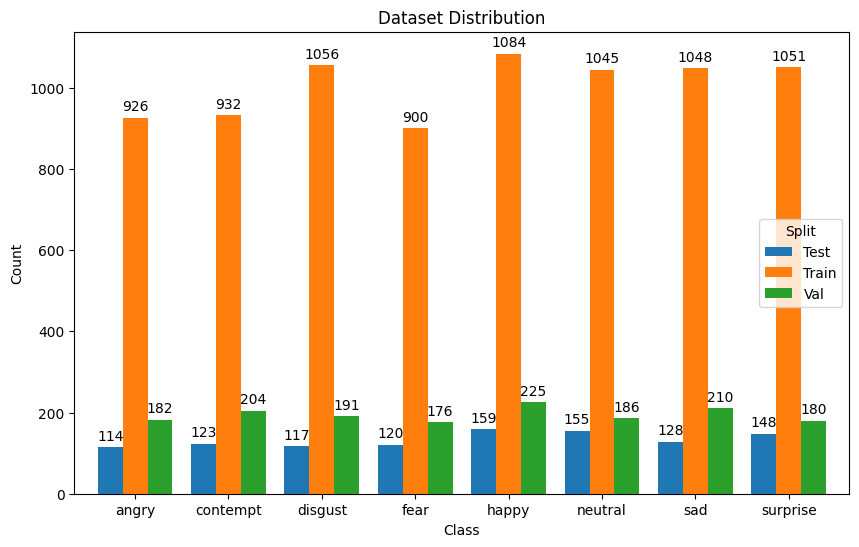

In [3]:
df_after_cleaned = get_distribution(DATASET_DIR)
plot_data_distribution(df_after_cleaned)

In [9]:
import hashlib
from pathlib import Path
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

dataset_dir = globals().get('DATASET_DIR', resolve_dataset_path('dataset') if 'resolve_dataset_path' in globals() else Path('../dataset').resolve())
train_path = dataset_dir / "Val"
if not train_path.exists():
    train_path = dataset_dir

image_extensions = globals().get('IMAGE_EXTENSIONS', {'.jpg', '.jpeg', '.png', '.bmp', '.webp'})


def image_count_for_augmentation(path):
    if 'count_images' in globals():
        return count_images(path)
    return sum(1 for file_path in Path(path).iterdir() if file_path.is_file() and file_path.suffix.lower() in image_extensions)

minority_classes = ['disgust', 'contempt', 'fear','neutral', 'angry', 'sad', 'surprise', 'happy']
class_count = {d.name: image_count_for_augmentation(d) for d in train_path.iterdir() if d.is_dir()}
minority_classes = [cls for cls in minority_classes if cls in class_count]
if not class_count:
    raise ValueError(f"No class folders found for augmentation in: {train_path}")
target_count = max(class_count.values())

datagen = ImageDataGenerator(
    rotation_range = 15,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    brightness_range = [0.8, 1.2],
    zoom_range = 0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

for cls in minority_classes:
    class_path = train_path / cls
    current_count = class_count[cls]
    needed = target_count - current_count
    if needed <= 0: continue

    print(f'Augmenting {cls}: Needed {needed} images')
    img_paths = [p for p in class_path.iterdir() if p.is_file() and p.suffix.lower() in image_extensions]
    if not img_paths:
        print(f'Skipping {cls}: no source images')
        continue
    i = 0
    while i < needed:
        for p in img_paths:
            if i >= needed: break
            
            img = load_img(p)
            x = img_to_array(img)
            x = x.reshape((1,) + x.shape)

            for batch in datagen.flow(x, batch_size=1, save_to_dir=class_path, save_prefix='aug', save_format='jpg'):
                i += 1
                break
print("Data augmentation completed.")

Augmenting disgust: Needed 34 images
Augmenting contempt: Needed 21 images
Augmenting fear: Needed 49 images
Augmenting neutral: Needed 39 images
Augmenting angry: Needed 43 images
Augmenting sad: Needed 15 images
Augmenting surprise: Needed 45 images
Data augmentation completed.


Visualization

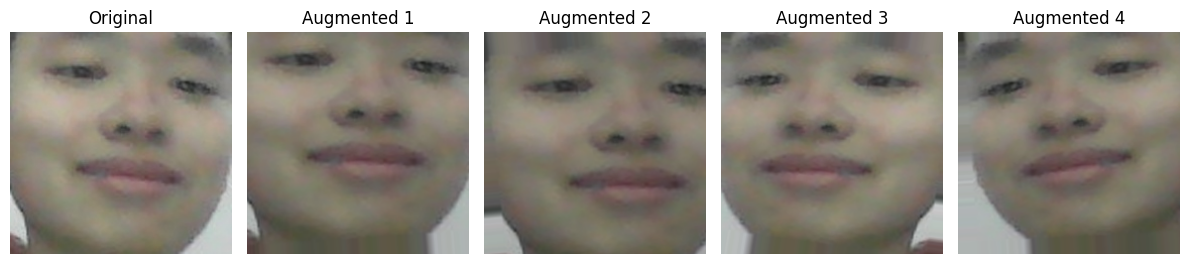

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_augmentation(image_path):
    img = load_img(image_path)
    x = img_to_array(img)
    x = x.reshape((1,) + x.shape)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 5, 1)
    plt.title('Original')
    plt.imshow(img)
    plt.axis('off')

    i = 2
    for batch in datagen.flow(x, batch_size=1):
        plt.subplot(1, 5, i)
        plt.title(f'Augmented {i-1}')
        plt.imshow(batch[0].astype('uint8'))
        plt.axis('off')
        i += 1
        if i > 5: break
    plt.tight_layout()
    plt.show()

sample_image = next((train_path / 'happy').glob('*.jpg'))
visualize_augmentation(sample_image)

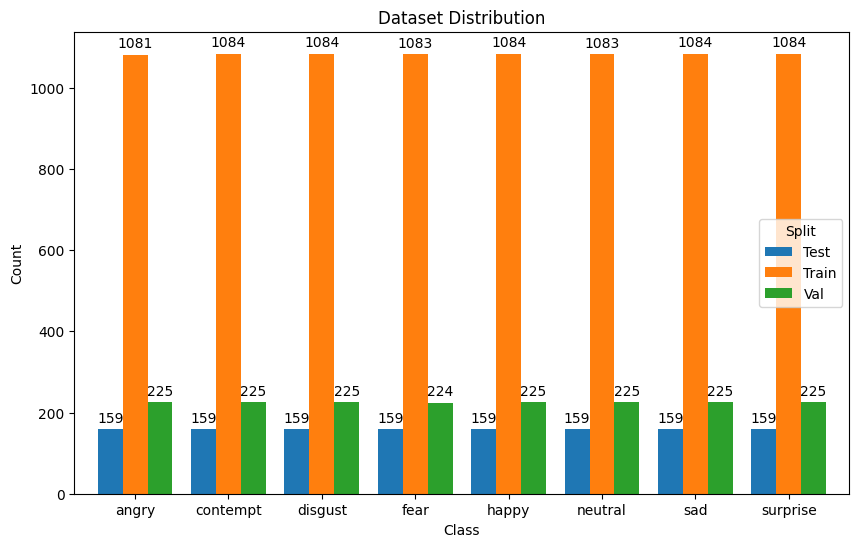

In [10]:
df_completed = get_distribution(DATASET_DIR)
plot_data_distribution(df_completed)